<a href="https://colab.research.google.com/github/anabiarochar/Mestrado_MLG/blob/main/scikit-ML-AnaRibeiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Árvores de Decisão, Seleção de Atributos e de Modelos**

---





# Caso: **Pima Indians Diabetes**

https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv






In [ ]:
import pandas as pd
import numpy as np

# URL do dataset (Repositório UCI via GitHub)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Definindo os nomes das colunas em Português
colunas = [
    'gravidez', 'glicose', 'pressao', 'espessura_triceps',
    'insulina', 'imc', 'historico_familiar', 'idade', 'resultado'
]

# Carregando o arquivo
df = pd.read_csv(url, names=colunas)

print("Primeiras linhas do dataset:")
print(df.head())



Primeiras linhas do dataset:
   gravidez  glicose  pressao  espessura_triceps  insulina   imc  \
0         6      148       72                 35         0  33.6   
1         1       85       66                 29         0  26.6   
2         8      183       64                  0         0  23.3   
3         1       89       66                 23        94  28.1   
4         0      137       40                 35       168  43.1   

   historico_familiar  idade  resultado  
0               0.627     50          1  
1               0.351     31          0  
2               0.672     32          1  
3               0.167     21          0  
4               2.288     33          1  


In [ ]:
# Substituindo 0 por NaN em colunas onde o valor zero é fisicamente impossível
cols_com_zeros = ['glicose', 'pressao', 'espessura_triceps', 'insulina', 'imc']
df[cols_com_zeros] = df[cols_com_zeros].replace(0, np.nan)

for col in cols_com_zeros:
    df[col] = df[col].fillna(df[col].median())


# Exercício 1. Label Encode e Conjuntos de Treinamento e Teste


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('resultado', axis=1)
y = df['resultado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Exercício 2. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print( f'{clf.score(X_test,y_test):.4f}' )

0.7597


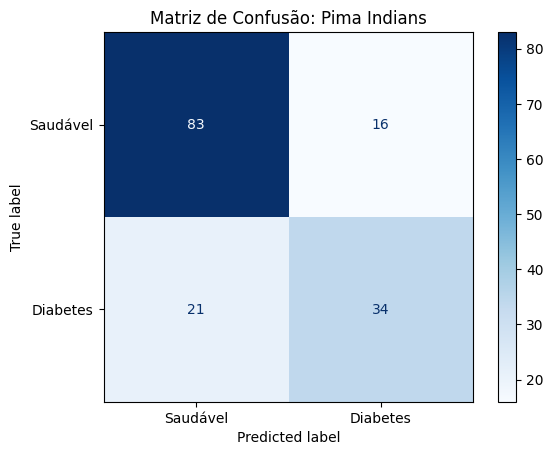


Relatório de Classificação:

              precision    recall  f1-score   support

    Saudável       0.80      0.84      0.82        99
    Diabetes       0.68      0.62      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saudável', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão: Pima Indians')
plt.show()


print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred, target_names=['Saudável', 'Diabetes']))

# Exercício 3. Normalize os dados

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print( f'{clf.score(X_test,y_test):.4f}' )

0.7597


# Exercício 4. Cross-Validation


In [ ]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42) # random_state=42 para reprodução!

cv_scores = cross_val_score(clf, X_train, y_train, cv=kf)

print("Cross-validation scores:", cv_scores)
print("Average cross-validation accuracy:", cv_scores.mean())


Cross-validation scores: [0.70731707 0.74796748 0.69918699 0.67479675 0.7295082 ]
Average cross-validation accuracy: 0.7117552978808476


# Exercício 5. Feature Selection


In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information
mutual_info = mutual_info_classif(X_train, y_train)

# Create a DataFrame to store feature names and their mutual information scores
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Mutual Information': mutual_info})

# Sort the DataFrame by mutual information in descending order
feature_importance_df = feature_importance_df.sort_values('Mutual Information', ascending=False)

# Display the feature importance
print(feature_importance_df)

              Feature  Mutual Information
1             glicose            0.119485
4            insulina            0.083830
5                 imc            0.083384
7               idade            0.062561
0            gravidez            0.054737
6  historico_familiar            0.034775
3   espessura_triceps            0.008790
2             pressao            0.006557


In [ ]:
X_train[feature_importance_df[0:5].Feature.values]

,glicose,insulina,imc,idade,gravidez
60,84.0,125.0,32.3,21,2
618,112.0,125.0,28.2,50,9
346,139.0,83.0,28.7,22,1
294,161.0,125.0,21.9,65,0
231,134.0,370.0,46.2,46,6
...,...,...,...,...,...
71,139.0,140.0,28.6,26,5
106,96.0,125.0,22.4,27,1
270,101.0,125.0,45.6,38,10
435,141.0,125.0,42.4,29,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf.fit(X_train[feature_importance_df[0:5].Feature.values],y_train)
y_pred = clf.predict(X_test[feature_importance_df[0:5].Feature.values])
print(f"Acurácia Decision Tree {clf.score(X_test[feature_importance_df[0:5].Feature.values],y_test):.4f}")

Acurácia Decision Tree 0.7727


# Exercício 6. GridSearchCV


In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Definimos o "dicionário" de parâmetros que queremos testar
parametros = {
    'max_depth': [3, 5, 7, 10, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}

# 2. Criamos o objeto GridSearchCV
# cv=5 significa que ele fará Cross-Validation de 5 dobras para CADA combinação
grid = GridSearchCV(DecisionTreeClassifier(), parametros, cv=5, scoring='accuracy')

# 3. Ele testa tudo automaticamente
grid.fit(X_train, y_train)

# 4. Resultados mágicos:
print("Melhores Parâmetros:", grid.best_params_)
print("Melhor Acurácia:", grid.best_score_)

Melhores Parâmetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Melhor Acurácia: 0.7524990003998401


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

model_params = {
    'DecisionTreeClassifier': {
        'model': DecisionTreeClassifier(),
        'params': {
            'criterion': ['gini', 'entropy'],
            'max_depth': [3, 5, 10, None],
            'min_samples_leaf': [1, 5, 10]
        }
    },
    'RandomForestClassifier': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, None],
            'bootstrap': [True, False]
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(solver='liblinear', max_iter=1000),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'penalty': ['l1', 'l2']
        }
    },
    'SVC': {
        'model': SVC(),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    }
}

best_models = {}

for model_name, mp in model_params.items():
    print(f'Model {model_name}...')
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='accuracy')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    best_models[model_name] = (clf.best_estimator_, accuracy)

best_model_name = max(best_models, key=lambda k: best_models[k][1])
best_model, best_accuracy = best_models[best_model_name]

print(f"Melhor modelo: {best_model_name}")
print(f"Melhor acurácia: {best_accuracy}")
print(f"Melhor modelo encontrado: {best_model}")


Model DecisionTreeClassifier...
Model RandomForestClassifier...
Model LogisticRegression...
Model SVC...
Melhor modelo: SVC
Melhor acurácia: 0.7597402597402597
Melhor modelo encontrado: SVC(C=10, kernel='linear')


# Exercício 7. E agora?

Selecionando o melhor modelo para usar, antes de aplicá-lo é importante verificar a possibilidade de retirar alguns atributos e assim melhorar a acurácia


In [ ]:
X_all = X_train

# Seleção de Atributos
top_features = ['glicose', 'imc', 'idade', 'insulina','gravidez']
X_selected = X_train[top_features]

# Ajustando o X_test também para a comparação final
X_test_selected = X_test[top_features]

In [ ]:
results = []

for name, mp in model_params.items():
    # Teste 1: Com todos os atributos
    grid_all = GridSearchCV(mp['model'], mp['params'], cv=5)
    grid_all.fit(X_all, y_train)
    acc_all = grid_all.score(X_test, y_test)

    # Teste 2: Com atributos selecionados
    grid_sel = GridSearchCV(mp['model'], mp['params'], cv=5)
    grid_sel.fit(X_selected, y_train)
    acc_sel = grid_sel.score(X_test_selected, y_test)

    results.append({
        'Modelo': name,
        'Acurácia (Todos)': round(acc_all, 4),
        'Acurácia (Selecionados)': round(acc_sel, 4),
        'Diferença': round(acc_sel - acc_all, 4)
    })

df_comparativo = pd.DataFrame(results)
print(df_comparativo.sort_values(by='Acurácia (Selecionados)', ascending=False))

                   Modelo  Acurácia (Todos)  Acurácia (Selecionados)  \
2      LogisticRegression            0.7532                   0.7727   
3                     SVC            0.7597                   0.7662   
1  RandomForestClassifier            0.7468                   0.7468   
0  DecisionTreeClassifier            0.7338                   0.7143   

   Diferença  
2     0.0195  
3     0.0065  
1     0.0000  
0    -0.0195  


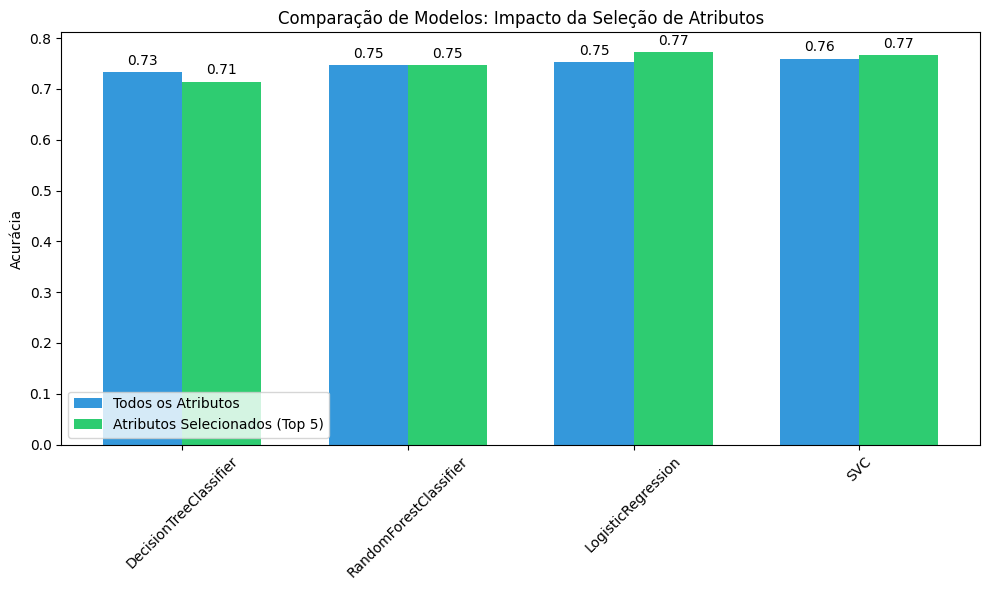

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Preparando os dados para o gráfico
modelos = df_comparativo['Modelo']
acc_todos = df_comparativo['Acurácia (Todos)']
acc_sel = df_comparativo['Acurácia (Selecionados)']

x = np.arange(len(modelos))  # Localização das labels
width = 0.35  # Largura das barras

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, acc_todos, width, label='Todos os Atributos', color='#3498db')
rects2 = ax.bar(x + width/2, acc_sel, width, label='Atributos Selecionados (Top 5)', color='#2ecc71')

# Adicionando textos, títulos e labels
ax.set_ylabel('Acurácia')
ax.set_title('Comparação de Modelos: Impacto da Seleção de Atributos')
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=45)
ax.legend()

# Função para colocar o valor em cima da barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

Chegando a conclusão de que o SVC seria um melhor modelo para utilizar

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(C=10, kernel='linear', random_state=42))
])

clf.fit(X_train[feature_importance_df[0:5].Feature.values],y_train)
y_pred = clf.predict(X_test[feature_importance_df[0:5].Feature.values])
print(f"Acurácia SVC: {clf.score(X_test[feature_importance_df[0:5].Feature.values],y_test):.4f}")


Acurácia SVC: 0.7662
